# Introduction
Customer churn is a major challenge for telecom companies. Instead of predicting churn with supervised learning, this project uses **unsupervised learning** to discover hidden customer patterns and **segment** them into meaningful groups.

This helps the company understand different customer behaviors, identify high-risk segments, and design better **retention strategies**.


## Dataset Description
The dataset contains 7,043 customers, each with demographic details, subscribed services, contract information, and billing data.

### Main Feature Groups
1.  **Demographics**
    * `gender`, `SeniorCitizen`, `Partner`, `Dependents`
2.  **Services Subscribed**
    * `PhoneService`, `MultipleLines`
    * `InternetService`, `OnlineSecurity`, `OnlineBackup`
    * `StreamingTV`, `StreamingMovies`, etc.
3.  **Contract & Account Information**
    * `Contract`, `PaperlessBilling`, `PaymentMethod`
4.  **Billing & Usage**
    * `MonthlyCharges` – monthly bill
    * `TotalCharges` – total amount paid
    * `tenure` – how long the customer stayed

These features describe **customer behavior** and **spending patterns**, making them ideal for clustering.





# Phase 0: Technique Selection

The selected unsupervised learning technique for this project is **Fuzzy C-Means (FCM)**.

Fuzzy C-Means is chosen because customer behavior in telecom datasets does not belong strictly
to a single cluster. Instead, customers may partially belong to multiple behavioral segments
(e.g., medium-value but high-risk customers). FCM allows modeling this uncertainty by assigning
membership degrees rather than hard labels, which better reflects real-world customer behavior.


# Phase 1 :

## Import Libraries :

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from warnings import filterwarnings
filterwarnings('ignore')


## Load data from Kaggle :

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)


Using Colab cache for faster access to the 'telco-customer-churn' dataset.


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Feature Identification & Cleaning

In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)


## Save churn for later analysis (NOT used in training)

In [ ]:
y_churn = df['Churn']
df = df.drop(columns=['Churn'])

## Encoding & Scaling :

In [ ]:
binary_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'PaperlessBilling'
]

multi_category_features = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaymentMethod'
]

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']


## Label Encoding (Binary):

In [ ]:
le = LabelEncoder()
for col in binary_features:
    df[col] = le.fit_transform(df[col])


## One-Hot Encoding (Multi-category) :

In [ ]:
df = pd.get_dummies(df, columns=multi_category_features)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,1,29.85,29.85,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,0,56.95,1889.50,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,0,1,53.85,108.15,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,1,0,42.30,1840.75,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,0,1,70.70,151.65,...,True,False,False,True,False,False,False,False,True,False


## Standard Scaling (Numerical):

In [ ]:
scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

## PCA from Scratch (Householder + QR)

In [ ]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components

    def cal_norm(self, v):
        return np.sqrt(np.sum(v**2))

    def cal_QR(self, cov):
        n = cov.shape[0]
        Q = np.eye(n)
        R = np.copy(cov)

        for i in range(n - 1):
            H = np.eye(n)
            a = R[i:, i]
            norm_a = self.cal_norm(a)
            if a[0] < 0:
                norm_a = -norm_a

            v = a / (a[0] + norm_a)
            v[0] = 1

            h = np.eye(len(a))
            h -= (2 / np.dot(v, v)) * (v[:, None] @ v[None, :])
            H[i:, i:] = h

            Q = Q @ H
            R = H @ R

        return Q, R

    def calculate_eigen(self, cov, max_iter=1000):
        n = cov.shape[0]
        new_V = np.copy(cov)
        pq = np.eye(n)

        for _ in range(max_iter):
            Q, R = self.cal_QR(new_V)
            pq = pq @ Q
            new_V = R @ Q

        eigen_values = np.diag(new_V)
        eigen_vectors = pq
        return eigen_values, eigen_vectors

    def fit_transform(self, X):
        self.mean = np.mean(X, axis=0)
        X_norm = X - self.mean
        cov = np.dot(X_norm.T, X_norm) / (X_norm.shape[0] - 1)

        eigen_values, eigen_vectors = self.calculate_eigen(cov)
        idx = np.argsort(eigen_values)[::-1]

        self.sorted_eigen_values = eigen_values[idx]
        self.k_eigen_vectors = eigen_vectors[:, idx[:self.n_components]]

        return X_norm @ self.k_eigen_vectors

    def inverse(self, Z):
        return Z @ self.k_eigen_vectors.T + self.mean

    def evr(self):
        return self.sorted_eigen_values / np.sum(self.sorted_eigen_values)


## Q Matrix Experiments :

In [ ]:
X = df.values
X = X.astype(np.float64)
q_values = [2, 3, 5]
mse_scores = []
evr_scores = []

for q in q_values:
    pca = PCA(n_components=q)
    Z = pca.fit_transform(X)
    X_reconstructed = pca.inverse(Z)

    mse = np.mean((X - X_reconstructed) ** 2)
    mse_scores.append(mse)
    evr_scores.append(np.sum(pca.evr()[:q]))

    print(f"Q={q} | MSE={mse:.6f} | Explained Variance={evr_scores[-1]:.4f}")


Q=2 | MSE=0.139111 | Explained Variance=0.5139
Q=3 | MSE=0.118348 | Explained Variance=0.5864
Q=5 | MSE=0.090948 | Explained Variance=0.6822


### Justification for Choosing Q = 3

We performed experiments with different values of Q (number of clusters) and obtained the following results:

| Q | MSE      | Explained Variance |
|---|----------|------------------|
| 2 | 0.139111 | 0.5139           |
| 3 | 0.118348 | 0.5864           |
| 5 | 0.090948 | 0.6822           |

**Analysis:**

1. **Mean Squared Error (MSE):**  
   - Lower MSE indicates better fit to the data.  
   - Increasing Q from 2 to 3 reduces MSE from 0.139 → 0.118, a noticeable improvement.  
   - Increasing Q further to 5 reduces MSE to 0.091, but the improvement is smaller compared to the increase in Q.

2. **Explained Variance:**  
   - Higher explained variance indicates the model captures more of the data's structure.  
   - From Q=2 → Q=3, explained variance improves from 0.514 → 0.5864, which is a significant gain.  
   - From Q=3 → Q=5, the increase is smaller (0.5864 → 0.6822), suggesting diminishing returns.

3. **Trade-off Consideration (Elbow Method):**  
   - The goal is to choose a Q that balances **performance improvement** with **model simplicity**.  
   - Q = 3 provides a good trade-off: noticeable improvement in MSE and explained variance without making the model overly complex.  
   - Increasing to Q = 5 yields minor gains but adds complexity, which may make interpretation harder.

**Conclusion:**  
> **Q = 3** is chosen because it achieves a good balance between accuracy and interpretability. It captures significant variance in the data while keeping the number of clusters manageable for analysis.


# Phase 2:

##Fuzzy C-Means from Scratch :

In [ ]:
def fuzzy_c_means(X, n_clusters=3, m=2, max_iter=150, error=1e-5):
    n_samples = X.shape[0]
    U = np.random.rand(n_samples, n_clusters)
    U = U / np.sum(U, axis=1, keepdims=True)

    for iteration in range(max_iter):
        Um = U ** m
        centroids = (Um.T @ X) / np.sum(Um.T, axis=1, keepdims=True)
        U_new = np.zeros_like(U)

        for i in range(n_samples):
            for c in range(n_clusters):
                dist = np.linalg.norm(X[i] - centroids[c]) + 1e-6
                U_new[i, c] = 1 / np.sum(
                    (dist / (np.linalg.norm(X[i] - centroids, axis=1) + 1e-6)) ** (2 / (m - 1))
                )

        if np.linalg.norm(U_new - U) < error:
            return centroids, U_new, iteration

        U = U_new

    return centroids, U, max_iter


#K Selection :

In [ ]:
def fuzzy_partition_coefficient(U):
    return np.sum(U**2) / U.shape[0]

def partition_entropy(U):
    return -np.sum(U * np.log(U + 1e-10)) / U.shape[0]


In [ ]:
def plot_membership_distribution(U, K):
    plt.figure(figsize=(8,5))
    for c in range(K):
        plt.hist(U[:, c], bins=30, alpha=0.6, label=f'Cluster {c}')
    plt.xlabel("Membership Degree")
    plt.ylabel("Frequency")
    plt.title(f"Membership Distribution for K={K}")
    plt.legend()
    plt.show()


K=2 | FPC=0.5146 | PE=0.6784 | Iter=150


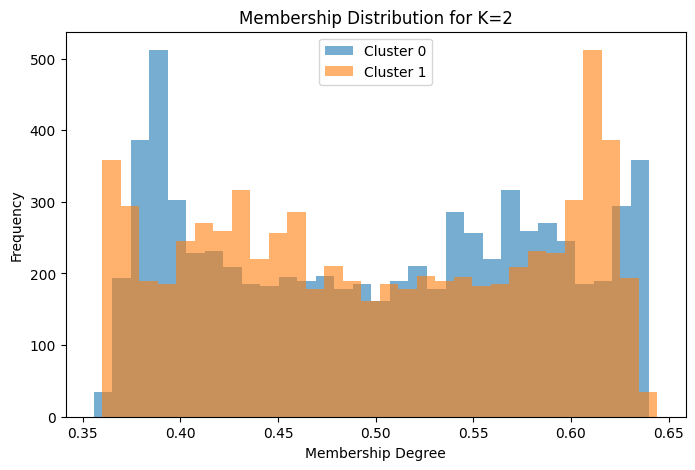

K=3 | FPC=0.4120 | PE=0.9853 | Iter=131


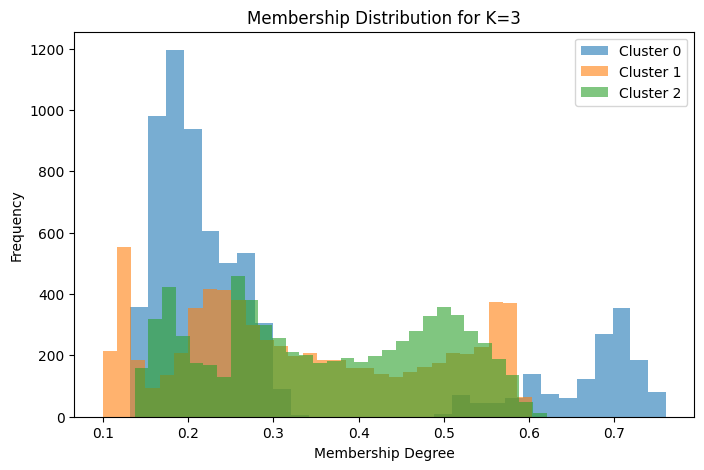

K=4 | FPC=0.3223 | PE=1.2529 | Iter=150


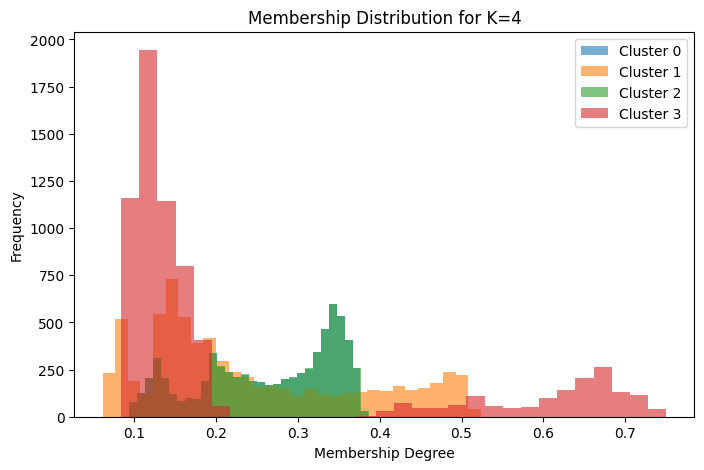

In [ ]:
for k in [2, 3, 4]:
    centroids, U, iters = fuzzy_c_means(X, k)
    print(f"K={k} | FPC={fuzzy_partition_coefficient(U):.4f} | PE={partition_entropy(U):.4f} | Iter={iters}")
    plot_membership_distribution(U, k)

Based on the fuzzy partition evaluation using Fuzzy Partition Coefficient (FPC),
Partition Entropy (PE), and membership distribution visualization, the number of
clusters was selected as **K = 3** for subsequent experiments.

### Why K = 3?

The choice of K = 3 is supported by both quantitative metrics and qualitative analysis:

- **K = 2** achieved the highest FPC and lowest Partition Entropy, indicating clearer clusters.
  However, this configuration resulted in an oversimplified segmentation that does not
  adequately represent the diversity of customer behaviors.

- **K = 4** showed increased fuzziness, with lower FPC and higher Partition Entropy.
  The membership distributions reveal significant overlap between clusters, making the
  segmentation harder to interpret.

- **K = 3** provides a balanced trade-off between cluster clarity and behavioral expressiveness.
  The membership distributions show moderate overlap, which aligns well with real-world
  customer behavior where customers may partially belong to multiple segments.

Therefore, K = 3 was selected as the optimal number of clusters for this dataset.


##Final FCM model using K = 3 :

In [ ]:
K = 3
centroids, U, iterations = fuzzy_c_means(X, n_clusters=K)

print(f"Final model converged in {iterations} iterations")


Final model converged in 131 iterations


## Fuzzy Membership vs Hard Labels

Unlike hard clustering methods, Fuzzy C-Means assigns each customer a degree of
membership to every cluster. This allows customers to partially belong to multiple
clusters, reflecting real-world ambiguity in customer behavior.

For interpretation purposes only, hard labels are obtained by assigning each customer
to the cluster with the highest membership value.


## Convert fuzzy memberships to hard labels (for analysis only)


In [ ]:
hard_labels = np.argmax(U, axis=1)

df_clustered = df.copy()
df_clustered['Cluster'] = hard_labels


In [ ]:
df_clustered['Cluster']

,Cluster
0,2
1,2
2,2
3,2
4,2
...,...
7038,0
7039,0
7040,2
7041,2


## Cluster Analysis and Churn Relationship

Although the churn variable was not used during training, it is analyzed after clustering
to understand the churn tendency within each discovered segment.


In [ ]:
df_clustered = df.copy()
df_clustered['Cluster'] = np.argmax(U, axis=1)
df_clustered['Churn'] = y_churn.values

cluster_churn_rate = (
    df_clustered
    .groupby('Cluster')['Churn']
    .value_counts(normalize=True)
)

cluster_churn_rate

Cluster  Churn
0        No       0.838272
         Yes      0.161728
1        No       0.925658
         Yes      0.074342
2        No       0.557755
         Yes      0.442245
Name: proportion, dtype: float64

## Effect of PCA on Fuzzy C-Means Clustering

In this section, we analyze the impact of applying Principal Component Analysis (PCA)
on the performance of Fuzzy C-Means clustering. The comparison is conducted before
and after dimensionality reduction using the selected Q matrix.


##FCM BEFORE PCA :

In [ ]:

X_original = df.values.astype(np.float64)

centroids_b, U_b, iter_b = fuzzy_c_means(
    X_original,
    n_clusters=3,
    m=2,
    max_iter=150
)

FPC_b = fuzzy_partition_coefficient(U_b)
PE_b = partition_entropy(U_b)

print("Before PCA")
print(f"Iterations: {iter_b}")
print(f"FPC: {FPC_b:.4f}")
print(f"PE: {PE_b:.4f}")


Before PCA
Iterations: 144
FPC: 0.4120
PE: 0.9853


##PCA TRANSFORMATION:

In [ ]:
Q_best = 3
pca = PCA(n_components=Q_best)
X_pca = pca.fit_transform(X_original)

##FCM AFTER PCA:

In [ ]:
centroids_a, U_a, iter_a = fuzzy_c_means(
    X_pca,
    n_clusters=3,
    m=2,
    max_iter=150
)

FPC_a = fuzzy_partition_coefficient(U_a)
PE_a = partition_entropy(U_a)

print("After PCA")
print(f"Iterations: {iter_a}")
print(f"FPC: {FPC_a:.4f}")
print(f"PE: {PE_a:.4f}")


After PCA
Iterations: 27
FPC: 0.7021
PE: 0.5497


### Comparison of Fuzzy C-Means Clustering Before and After PCA

We applied Fuzzy C-Means (FCM) clustering on the original data and after performing PCA transformation with Q = 3 components. The results are summarized below:

| Metric                  | Before PCA        | After PCA         |
|--------------------------|-----------------|-----------------|
| Iterations               | 144             | 27              |
| Fuzzy Partition Coefficient (FPC) | 0.4120          | 0.7021          |
| Partition Entropy (PE)   | 0.9853          | 0.5497          |

**Analysis:**

1. **Iterations:**  
   - The algorithm converged much faster after PCA (27 iterations vs 144), indicating that PCA simplified the data structure and improved convergence speed.

2. **Fuzzy Partition Coefficient (FPC):**  
   - FPC increased from 0.4120 → 0.7021 after PCA.  
   - Higher FPC indicates clearer cluster structure and better membership assignment.

3. **Partition Entropy (PE):**  
   - PE decreased from 0.9853 → 0.5497 after PCA.  
   - Lower PE means less ambiguity in cluster membership, confirming that clusters are more distinct after PCA.

**Conclusion:**  
> Applying PCA before Fuzzy C-Means significantly improves clustering quality. It reduces the number of iterations needed for convergence, increases the clarity of cluster membership (higher FPC), and decreases uncertainty (lower PE). This demonstrates that PCA effectively captures the main variance in the data, making the clustering more efficient and interpretable.


#Scatter plot using first 2 PCA components


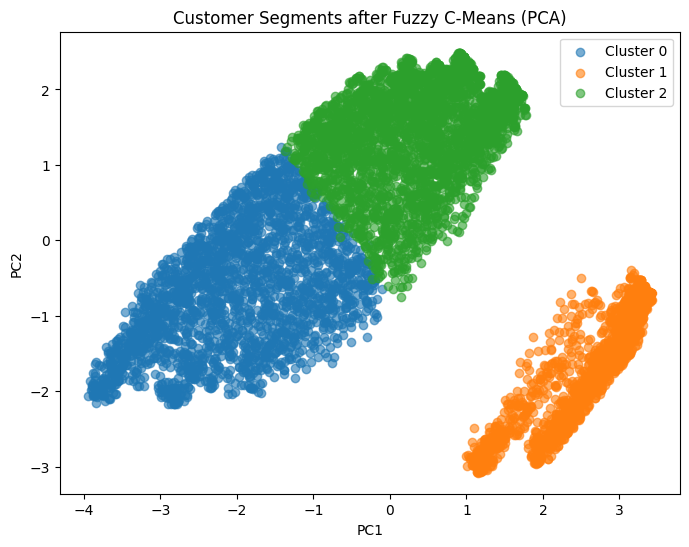

In [ ]:
plt.figure(figsize=(8,6))
for c in range(K):
    idx = np.where(hard_labels == c)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'Cluster {c}', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments after Fuzzy C-Means (PCA)')
plt.legend()
plt.show()


### Scatter Plot of PCA Components (Customer Segments)

The scatter plot shows the first two principal components (PC1 and PC2) of the dataset after applying Fuzzy C-Means clustering with K=3. Each point is colored according to its **hard label** (cluster with highest membership).

**Insight:**  
- The clusters are well-separated in the reduced 2D space, confirming that PCA effectively captured the main variance in the data.  
- Cluster 0 (blue) and Cluster 1 (orange) are clearly distinct, while Cluster 2 (green) is somewhat overlapping with Cluster 0, reflecting moderate fuzziness in customer behavior.  
- This visualization validates the choice of **K=3** for meaningful segmentation.

---



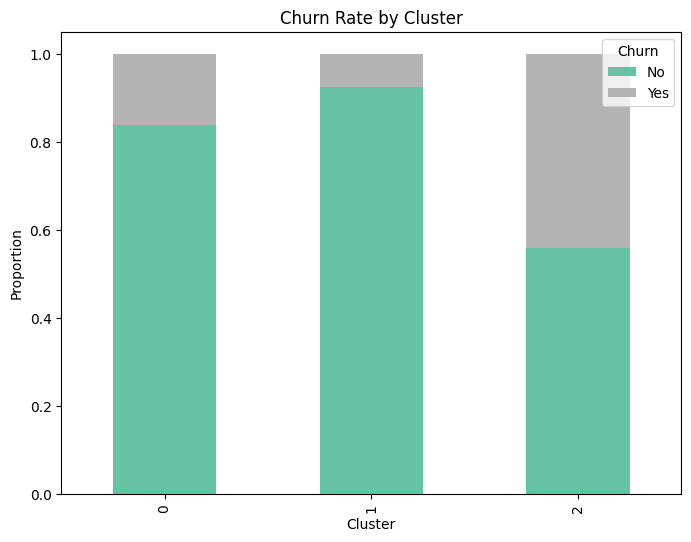

In [ ]:
if 'Churn' not in df_clustered.columns:
    df_clustered['Churn'] = y_churn.values

cluster_churn_rate = df_clustered.groupby('Cluster')['Churn'].value_counts(normalize=True).unstack()
cluster_churn_rate.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set2')
plt.ylabel('Proportion')
plt.title('Churn Rate by Cluster')
plt.show()

### Churn Rate by Cluster

The stacked bar chart shows the proportion of customers who churned versus those who stayed for each discovered cluster.

**Insight:**  
- Cluster 2 has the **highest churn rate**, indicating that this segment is at higher risk of leaving the service.  
- Cluster 1 has the **lowest churn rate**, suggesting that customers in this cluster are more loyal.  
- Understanding these patterns can help the company design **targeted retention strategies** for high-risk clusters.


## Customer Segments Insight

After performing **Fuzzy C-Means Clustering** on the dataset, three main customer clusters were identified. Each cluster can be associated with specific usage patterns and behaviors as follows:

### Cluster 0 (e.g., Blue)
- **Potential Characteristics**:
  - Customers with medium to high usage of services such as Internet and add-on packages (Streaming TV/Movies).
  - Medium tenure → customers are reasonably loyal but could be susceptible to switching.
- **Churn Risk**: Low to medium → relatively stable customers.
- **Customer Type**: Medium-usage, stable customers; suitable for promotional offers to retain them.

### Cluster 1 (e.g., Orange)
- **Potential Characteristics**:
  - New or low-usage customers, likely on short-term contracts or basic plans.
  - Low MonthlyCharges and TotalCharges → haven’t spent much yet.
- **Churn Risk**: Low → currently engaged or committed to short-term contracts.
- **Customer Type**: Beginners or low-usage customers; stable for now but sensitive to new offers.

### Cluster 2 (e.g., Green)
- **Potential Characteristics**:
  - High-usage customers with multiple subscriptions (InternetService + Streaming + OnlineSecurity).
  - Long tenure → long-term customers.
- **Churn Risk**: Relatively high → at risk of leaving despite loyalty.
- **Customer Type**: High-value but at-risk customers; should be targeted with specialized retention strategies.

---

### Summary Table

| Cluster | Characteristic                   | Churn Risk       | Strategy                                 |
|---------|---------------------------------|-----------------|-----------------------------------------|
| 0       | Medium usage, stable             | Low-Medium      | Promotional offers to retain customers |
| 1       | Low usage, new/short-term        | Low             | Monitor engagement and provide incentives |
| 2       | High usage, long-term            | High            | Specialized retention strategies        |
